In [1]:
from numba import njit # DO NOT REMOVE
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
%load_ext autoreload
%autoreload 2
import pylupnt as pnt

flag_plot = False
flag_save = False

# Setup

In [2]:
# Epoch(TAI)
t0_tai_str = "2022-01-15T00:00:00"
N_sat, N_planes = 2, 1

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 5740  # [km] Semi-major axis
ecc = [0.58, 0.58]  # [-] Eccentricity
inc = np.deg2rad([54.856, 54.856])  # [rad] Inclination
raan = np.deg2rad([0, 0])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([86.322, 86.322])  # [rad] Argument of periapsis
ma = np.deg2rad([0, 180])  # [rad] Mean anomaly

t0_tai = pnt.SpiceInterface.string_to_tai(t0_tai_str)
coe_op = np.zeros((N_sat, 6))
N_sat_plane = N_sat // N_planes
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i = i_pl * N_sat_plane + i_spl
        coe_op[i] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )

rv0_m2sc_op = pnt.classical_to_cartesian(coe_op, pnt.MU_MOON)
rv0_m2sc_mi = pnt.FrameConverter.convert(t0_tai, rv0_m2sc_op, pnt.MOON_OP, pnt.MOON_CI)

# Time
sma = coe_op[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
dt = 10  # [s] Simulation time step
dt_prop = 5  # [s] Propagation time step
tf = 0.5 * period  # [s] Simulation final time
N_t = int(tf / dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
tspan_h = tspan / pnt.SECS_PER_HOUR  # [h] Time since first epoch
t_tai = t0_tai + tspan  # [s] Epochs (TAI)

# Dynamics
dyn = pnt.NBodyDynamics()
dyn.set_primary_body(pnt.Body.Moon(5, 5))
dyn.add_body(pnt.Body.Earth())
# dyn.add_body(pnt.Body.Sun())
dyn.set_time_step(dt_prop)

dyn_ekf = pnt.NBodyDynamics()
dyn_ekf.set_primary_body(pnt.Body.Moon())
dyn_ekf.add_body(pnt.Body.Earth())
dyn_ekf.set_time_step(dt_prop)

# Propagation
# rv_from2to_frame [km, km/s] (x, y, z, vx, vy, vz)
rv_m2sc_mi = np.zeros((N_sat, N_t, 6))
rv_m2sc_pa = np.zeros((N_sat, N_t, 6))
for i in range(N_sat):
    rv_m2sc_mi[i] = dyn.propagate(rv0_m2sc_mi[i], t0_tai, t_tai)
    rv_m2sc_pa[i] = pnt.FrameConverter.convert(
        t_tai, rv_m2sc_mi[i], pnt.MOON_CI, pnt.MOON_PA
    )

rv_m2e_mi = pnt.SpiceInterface.get_body_pos_vel(t_tai, pnt.MOON, pnt.EARTH)
rv_m2e_pa = pnt.FrameConverter.convert(t_tai, rv_m2e_mi, pnt.MOON_CI, pnt.MOON_PA)
rv_m2s_mi = pnt.SpiceInterface.get_body_pos_vel(t_tai, pnt.MOON, pnt.SUN)
rv_m2s_pa = pnt.FrameConverter.convert(t_tai, rv_m2s_mi, pnt.MOON_CI, pnt.MOON_PA)

# Directions
e_sc2m = np.array(-rv_m2sc_mi[:, :, 0:3])
e_sc2s = np.array(rv_m2s_mi[None, :, 0:3] - rv_m2sc_mi[:, :, 0:3])
e_sc2e = np.array(rv_m2e_mi[None, :, 0:3] - rv_m2sc_mi[:, :, 0:3])
e_sc2m /= np.linalg.norm(e_sc2m, axis=2)[:, :, None]
e_sc2s /= np.linalg.norm(e_sc2s, axis=2)[:, :, None]
e_sc2e /= np.linalg.norm(e_sc2e, axis=2)[:, :, None]

# Yaw-Steering
ez_sc = e_sc2m
ey_sc = pnt.cross_norm(e_sc2m, e_sc2s)
ex_sc = pnt.cross_norm(ey_sc, ez_sc)

# Sun angle
sun_angle_cos = np.sum(e_sc2s * ex_sc, axis=2)
sun_angle = np.arccos(np.clip(sun_angle_cos, -1, 1))

# Passive rotation matrices
R_mi2sc = np.zeros((N_sat, N_t, 3, 3))
R_mi2sc[:, :, 0, :] = ex_sc
R_mi2sc[:, :, 1, :] = ey_sc
R_mi2sc[:, :, 2, :] = ez_sc

assert np.allclose(np.linalg.norm(ex_sc, axis=-1), 1)
assert np.allclose(np.linalg.norm(ey_sc, axis=-1), 1)
assert np.allclose(np.linalg.norm(ez_sc, axis=-1), 1)

R_pa2mi = np.zeros((N_t, 3, 3))
for i in range(N_t):
    R_pa2mi[i] = pnt.SpiceInterface.get_frame_conversion_matrix(
        t_tai[i], pnt.MOON_PA, pnt.MOON_CI
    )[:3, :3]

# Spacecraft frame
cam_dir = np.array([0, 0, 1])
cam_up = np.array([1, 0, 0])
cam_right = np.array([0, 1, 0])
ez_c = cam_dir
ey_c = -cam_up
ex_c = cam_right
R_sc2ocv = np.array([ex_c, ey_c, ez_c])

In [3]:
if flag_plot:
    fig = pnt.plot.plot_constellation(
        rv_m2sc_mi,
        scene=dict(
            xaxis_tickvals=np.arange(-4, 5, 2) * 1e3,
            yaxis_tickvals=np.arange(-4, 2, 2) * 1e3,
            zaxis_tickvals=np.arange(-6, 2, 2) * 1e3,
        ),
    )
    fig.add_trace(
        pnt.plot.get_body_trace(
            pnt.MOON,
            size_factor=2,
            r_b2s_pa=None,  # rv_m2s_pa[0, :3],
            alpha=0.5,
            R_b2frame=R_pa2mi[0],
        )
    )
    pnt.plot.set_view(fig, -80, 20, 2.5)
    step = 200
    kwargs = dict(length_scale=1e3, tip_scale=5e2, width=5)
    for i in range(N_sat):
        for t in range(0, N_t, step):
            pnt.plot.plot_frame(
                fig,
                rv_m2sc_mi[i, t],
                R_mi2sc[i, t],
                length_scale=1e3,
                tip_scale=5e2,
                width=5,
            )

    pnt.plot.plot_3d_arrow(
        fig,
        np.zeros(3),
        rv_m2s_mi[0, :3] / np.linalg.norm(rv_m2s_mi[0, :3]),
        color="gold",
        length_scale=3e3,
        tip_scale=8e2,
        width=5,
    )
    pnt.plot.plot_3d_arrow(
        fig,
        np.zeros(3),
        rv_m2e_mi[0, :3] / np.linalg.norm(rv_m2e_mi[0, :3]),
        color="brown",
        length_scale=3e3,
        tip_scale=8e2,
        width=5,
    )
    fig.update_layout(showlegend=True)
    if flag_save:
        fig.write_image("../figures/moon_constellation.pdf")
    fig.show()

In [4]:
# GPS measurements
N_planes = 6
N_sat_plane = 4
N_gps = N_planes * N_sat_plane

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 26600  # [km] Semi-major axis (approximate for GPS)
ecc = [0.001] * N_planes  # [-] Eccentricity
inc = np.deg2rad([55] * N_planes)  # [rad] Inclination (55 degrees for GPS)
raan = np.deg2rad(
    [60 * i for i in range(N_planes)]
)  # [rad] RAAN, 60 degrees separation
aop = np.deg2rad([0] * N_planes)  # [rad] Argument of periapsis
ma = [np.deg2rad(0 + 90 * i) for i in range(N_sat_plane)]  # [rad] Mean anomaly

coe_gps_eci = []

# Populate the orbital elements array
coe_gps_eci = np.zeros((N_gps, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i = i_pl * N_sat_plane + i_spl

        coe_gps_eci[i] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )

rv0_gps_eci = pnt.classical_to_cartesian(coe_gps_eci, pnt.MU_EARTH)

dyn_gps = pnt.CartesianTwoBodyDynamics(pnt.MU_EARTH)
rv_gps_eci = np.zeros((N_gps, N_t, 6))
rv_gps_mi = np.zeros((N_gps, N_t, 6))
for i in range(N_gps):
    rv_gps_eci[i] = dyn_gps.propagate(
        rv0_gps_eci[i], t0_tai, t_tai, dt_prop, progress=True
    )
    rv_gps_mi[i] = pnt.FrameConverter.convert(
        t_tai, rv_gps_eci[i], pnt.ECI, pnt.MOON_CI
    )

In [5]:
if flag_plot:
    tickvals = np.arange(-30, 31, 10) * 1e3
    fig = pnt.plot.plot_constellation(
        rv_gps_eci,
        scene=dict(
            xaxis_tickvals=tickvals,
            yaxis_tickvals=tickvals,
            zaxis_tickvals=tickvals,
        ),
    )
    fig.add_trace(
        pnt.plot.get_body_trace(
            pnt.EARTH,
            size_factor=5,
        )
    )
    pnt.plot.set_view(fig, 50, 20, 2.5)
    if flag_save:
        fig.write_image("../figures/gnss/gps_constellation.pdf")
    fig.show()

In [6]:
if flag_plot:
    r_plot = np.linalg.norm(rv_m2e_mi[0]) * np.array([1, 0, 0, 0, 0, 0])
    fig = pnt.plot.plot_constellation(rv_m2sc_mi, marker_size=3)
    pnt.plot.plot_constellation(
        rv_gps_eci + r_plot,
        fig=fig,
        marker_size=3,
        scene=dict(
            xaxis_tickvals=np.arange(0, 350, 50) * 1e3,
            yaxis_tickvals=np.arange(-20, 21, 10) * 1e3,
            zaxis_tickvals=np.arange(-20, 21, 10) * 1e3,
        ),
    )
    fig.add_trace(pnt.plot.get_body_trace(pnt.MOON, size_factor=10))
    fig.add_trace(pnt.plot.get_body_trace(pnt.EARTH, size_factor=10, r_body=r_plot))
    pnt.plot.set_view(fig, 200, 5, 5)
    fig.update_layout(showlegend=False, margin=dict(l=0, r=0, b=0, t=0))
    if flag_save:
        fig.write_image("../figures/gnss/moon_gnss_constellation.pdf")
    fig.show()

In [7]:
def compute_visibility(
    r1: np.ndarray, r2: np.ndarray, R_body: float, r_body: np.ndarray = None
) -> np.ndarray:
    if r_body is None:
        r_body = np.zeros(3)
    r = r2 - r1
    r_norm = np.linalg.norm(r, axis=1)
    r1body = r1 - r_body
    r1body_norm = np.linalg.norm(r1body, axis=1)
    dot = np.einsum("ij,ij->i", -r1body, r)
    theta1 = np.arccos(np.clip(dot / r_norm / r1body_norm, -1, 1))
    theta2 = np.arcsin(R_body / r1body_norm)
    visibility = np.ones(len(r1), dtype=bool)
    visibility[(theta1 < theta2) & (r_norm > r1body_norm)] = False
    return visibility

In [8]:
# Visibility
vis_sat_sat = np.ones((N_sat, N_sat, N_t), dtype=bool)
vis_sat_gps = np.ones((N_sat, N_gps, N_t), dtype=bool)
dist_sat_sat = np.zeros((N_sat, N_sat, N_t))
dist_sat_gps = np.zeros((N_sat, N_gps, N_t))
elev_gps_sat = np.zeros((N_sat, N_gps, N_t))
elev_sat_gps = np.zeros((N_sat, N_gps, N_t))

for i in range(N_sat):
    for j in range(i + 1, N_sat):
        vis_sat_sat[i, j] &= compute_visibility(
            rv_m2sc_mi[i, :, :3], rv_m2sc_mi[j, :, :3], pnt.R_MOON
        )
        vis_sat_sat[j, i] &= vis_sat_sat[i, j]
        dist_sat_sat[i, j] = np.linalg.norm(
            rv_m2sc_mi[i, :, :3] - rv_m2sc_mi[j, :, :3], axis=1
        )
        dist_sat_sat[j, i] = dist_sat_sat[i, j]

    for j in range(N_gps):
        vis_sat_gps[i, j] &= compute_visibility(
            rv_m2sc_mi[i, :, :3], rv_gps_mi[j, :, :3], pnt.R_MOON
        )
        vis_sat_gps[i, j] &= compute_visibility(
            rv_m2sc_mi[i, :, :3], rv_gps_mi[j, :, :3], pnt.R_EARTH, rv_m2e_mi[:, :3]
        )
        dist_sat_gps[i, j] = np.linalg.norm(
            rv_m2sc_mi[i, :, :3] - rv_gps_mi[j, :, :3], axis=1
        )

        r_gps2sc = rv_m2sc_mi[i, :, :3] - rv_gps_mi[j, :, :3]
        r_gps2sc /= np.linalg.norm(r_gps2sc, axis=1)[:, None]
        r_gps2e = rv_m2e_mi[:, :3] - rv_gps_mi[j, :, :3]
        r_gps2e /= np.linalg.norm(r_gps2e, axis=1)[:, None]
        elev_gps_sat[i, j] = np.arccos(
            np.clip(np.sum(r_gps2sc * r_gps2e, axis=1), -1, 1)
        )

        r_sc2e = rv_m2e_mi[:, :3] - rv_m2sc_mi[i, :, :3]
        r_sc2e /= np.linalg.norm(r_sc2e, axis=1)[:, None]
        r_sc2gps = rv_gps_mi[j, :, :3] - rv_m2sc_mi[i, :, :3]
        r_sc2gps /= np.linalg.norm(r_sc2gps, axis=1)[:, None]
        elev_sat_gps = np.arccos(np.clip(np.sum(r_sc2e * r_sc2gps, axis=1), -1, 1))

    vis_sat_sat[i, i, :] = False

In [9]:
def clock_sigma(cmodel, dt):
    if cmodel == "csac":
        sigmas = np.array([3e-10, 3e-12])
    elif cmodel == "rafs":
        # "Lunar Relay Onbord Navigation Performance and Effects on Lander Descent to Surface"
        sigmas = np.array([np.sqrt(3.70e-24), np.sqrt(1.87e-33)])
    elif cmodel == "mini-rafs":
        sigmas = np.array([1e-11, 1.1e-15])
    elif cmodel == "uso":
        # "Lunar Relay Onbord Navigation Performance and Effects on Lander Descent to Surface"
        sigmas = np.array([np.sqrt(2.53e-23), np.sqrt(4.22e-24)])
    return sigmas


def clock_process_noise(cmodel, dt):
    sigmas = clock_sigma(cmodel, dt)  # power spectrum density
    sig1 = sigmas[0]
    sig2 = sigmas[1]
    q11 = sig1**2 * dt + sig2**2 * dt**3 / 3
    q12 = sig2**2 * dt**2 / 2
    q22 = sig2**2 * dt
    Q = np.array([[q11, q12], [q12, q22]])
    return Q


def orbit_process_noise(sig_acc, dt):
    Q = np.zeros((6, 6))
    Q[:3, :3] = (dt**4) / 3 * sig_acc**2 * np.eye(3)
    Q[:3, 3:] = (dt**3) / 2 * sig_acc**2 * np.eye(3)
    Q[3:, :3] = (dt**3) / 2 * sig_acc**2 * np.eye(3)
    Q[3:, 3:] = (dt**2) * sig_acc**2 * np.eye(3)
    return Q

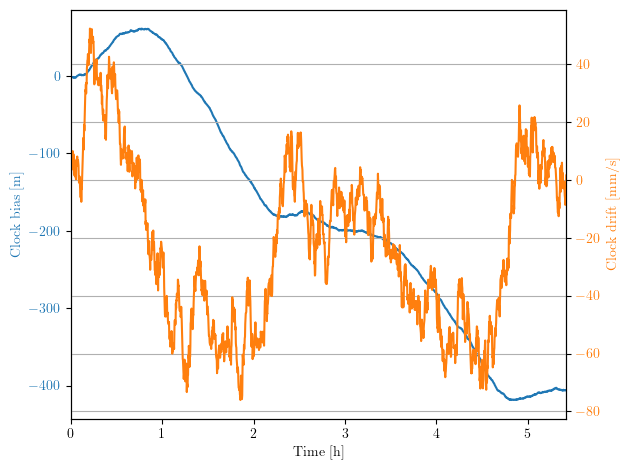

In [10]:
# True clock
np.random.seed(0)
clock_model = "csac"
stm_clk = np.array([[1, dt], [0, 1]])
Q_clk = pnt.C**2 * clock_process_noise(clock_model, dt=dt)

clk = np.zeros((N_sat, N_t, 2))
clk[:, 0] = np.array([0, 0])
for i in range(N_sat):
    for t in range(1, N_t):
        noise = np.random.multivariate_normal(np.zeros(2), Q_clk)
        clk[i, t] = stm_clk @ clk[i, t - 1] + noise

x_true = np.concatenate((rv_m2sc_mi, clk), axis=-1)

plt.figure()
plt.xlabel("Time [h]")
plt.xlim(tspan_h[0], tspan_h[-1])
plt.plot(tspan_h, clk[0, :, 0] * 1e3, color=pnt.plot.COLORS[0])
plt.ylabel("Clock bias [m]", color=pnt.plot.COLORS[0])
plt.gca().tick_params(axis="y", labelcolor=pnt.plot.COLORS[0])
# Right axis
plt.twinx()
plt.plot(tspan_h, clk[0, :, 1] * 1e6, color=pnt.plot.COLORS[1])
plt.ylabel("Clock drift [mm/s]", color=pnt.plot.COLORS[1])
plt.gca().tick_params(axis="y", labelcolor=pnt.plot.COLORS[1])
plt.grid()
plt.tight_layout()
plt.show()

# GPS + ISL

In [11]:
import plotly.graph_objects as go
import plotly.io as pio
import os

gps_pattern = np.loadtxt(
    os.path.join(pnt.LUPNT_DATA_PATH, "antenna", "GPS", "txt", "Block-IIA_ACE.txt"),
    delimiter=",",
)
gps_azimuths = np.concatenate((gps_pattern[0, 1:], [gps_pattern[0, 1]]))
gps_elevations = gps_pattern[1:, 0]
gps_gains = np.concatenate((gps_pattern[1:, 1:], gps_pattern[1:, 1][:, None]), axis=1)

# Create the meshgrid
AZ, EL = np.meshgrid(np.deg2rad(gps_azimuths), np.deg2rad(gps_elevations))
R = gps_gains - np.min(gps_gains)
X = R * np.cos(AZ) * np.sin(EL)
Y = R * np.sin(AZ) * np.sin(EL)
Z = R * np.cos(EL)

# Create the 3D surface plot
if flag_plot:
    fig = go.Figure()
    fig.add_surface(
        x=X,
        y=Y,
        z=Z,
        surfacecolor=gps_gains,
        colorscale="Viridis",
        colorbar=dict(title="Gain (dB)"),
    )
    tmp = dict(title="", showticklabels=False)
    fig.update_layout(scene=dict(xaxis=tmp, yaxis=tmp, zaxis=tmp))
    if flag_save:
        pio.write_image(fig, "../figures/gps_antenna_pattern.pdf")
    fig.show()

In [12]:
rx_pattern = np.loadtxt(
    os.path.join(pnt.LUPNT_DATA_PATH, "antenna", "GPSReceiver", "moongpsr.txt"),
    delimiter=",",
)
rx_azimuths = np.concatenate((rx_pattern[0, 1:], [rx_pattern[0, 1]]))
rx_elevations = rx_pattern[1:, 0]
rx_gains = np.concatenate((rx_pattern[1:, 1:], rx_pattern[1:, 1][:, None]), axis=1)

# Create the meshgrid
AZ, EL = np.meshgrid(np.deg2rad(rx_azimuths), np.deg2rad(rx_elevations))
min_gain = -20
R = np.maximum(rx_gains, min_gain) - min_gain
X = R * np.cos(AZ) * np.sin(EL)
Y = R * np.sin(AZ) * np.sin(EL)
Z = R * np.cos(EL)

# Create the 3D surface plot
if flag_plot:
    fig = go.Figure()
    fig.add_surface(
        x=X,
        y=Y,
        z=Z,
        surfacecolor=np.maximum(rx_gains, min_gain),
        colorscale="Viridis",
        colorbar=dict(title="Gain (dB)"),
    )
    tmp = dict(title="", showticklabels=False)
    fig.update_layout(scene=dict(xaxis=tmp, yaxis=tmp, zaxis=tmp))
    if flag_save:
        pio.write_image(fig, "../figures/gnss/rx_antenna_pattern.pdf")
    fig.show()

In [13]:
# Link budget
P_tx = 15  # [dBW] Transmitter power
freq = 1575.42e6  # [Hz] GPS L1 frequency
L_ad = 0.16  # [dB] A/D converter loss
L_atm = 0.0  # [dB] Atmospheric loss
Nf = 2.85  # [dB] Noise figure
Tsys = 290  # [K] System noise temperature
# [dB] Free space loss
L_fs = 20 * np.log10((4 * np.pi * dist_sat_gps) / (pnt.C / freq))
# [dB] Transmitter antenna gain
G_tx = np.interp(
    np.abs(elev_gps_sat), np.deg2rad(gps_elevations[:-1]), gps_gains[:-1, 0]
)
G_rx = np.interp(np.abs(elev_sat_gps), np.deg2rad(rx_elevations[:-1]), rx_gains[:-1, 0])
kb_db = 10 * np.log10(1.38e-23)  # [dB] Boltzmann constant
CN0 = P_tx + G_tx + G_rx - L_atm - L_fs - L_ad - Nf - kb_db - 10 * np.log10(Tsys)
CN0_threshold = 15  # [dB-Hz] CN0 thresholds

Bp_loop = 5.0  # [Hz] Carrier loop noise bandwidth
T_loop = 20e-3  # [s] Tracking loop integration time
b_loop = 2.0  # [-] Normalized bandwidth
Bn_loop = 0.2  # [Hz] Code loop noise bandwidth
D_loop = 0.3  # [-] Early-to-late correlator spacing (chips)

In [14]:
if flag_plot:
    plt.rcParams.update({"font.size": 16})
    plt.figure(figsize=(8, 4.5))
    plt.plot(gps_elevations, gps_gains[:, 0], label="GPS antenna")
    plt.plot(rx_elevations, rx_gains[:, 0], label="Receiver antenna")
    plt.xlabel("Elevation [deg]")
    plt.ylabel("Gain [dB]")
    plt.grid()
    plt.xlim(0, 90)
    plt.ylim(-25, 20)
    plt.legend()
    plt.tight_layout()
    if flag_save:
        plt.savefig("../figures/gnss/antenna_pattern.pdf")
    plt.show()

    plt.figure(figsize=(8, 4.5))
    i = 1
    ylims = [5, 35]
    for i in range(1):
        y = CN0[i]
        y[~vis_sat_gps[i]] = np.nan
        plt.plot(tspan_h, y.T, linewidth=1)
    plt.axhline(CN0_threshold, color="black", linestyle="--", label="Threshold")
    plt.xlim(tspan_h[0], tspan_h[-1])
    plt.ylim(ylims)
    plt.xlabel("Time [h]")
    plt.ylabel("C/N0 [dB-Hz]")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    if flag_save:
        plt.savefig("../figures/gnss/cn0.pdf")
    plt.show()

    plt.figure(figsize=(8, 4.5))
    for i in range(N_sat):
        y = np.sum(CN0[i] > CN0_threshold, axis=0)
        plt.step(tspan_h, y.T, label=f"Satellite {i+1}")
    plt.xlim(tspan_h[0], tspan_h[-1])
    plt.xlabel("Time [h]")
    plt.ylabel("Visible GPS satellites")
    plt.legend(loc="upper right")
    plt.ylim(0, 8)
    plt.grid()
    plt.tight_layout()
    if flag_save:
        plt.savefig("../figures/gnss/visible_gps_satellites.pdf")
    plt.show()

In [15]:
if flag_plot:
    fig = pnt.plot.plot_constellation(
        rv_m2sc_mi,
        scene=dict(
            xaxis_tickvals=np.arange(-4, 5, 2) * 1e3,
            yaxis_tickvals=np.arange(-4, 2, 2) * 1e3,
            zaxis_tickvals=np.arange(-6, 2, 2) * 1e3,
        ),
    )
    fig.add_trace(pnt.plot.get_body_trace(pnt.MOON, size_factor=2))
    for t in range(0, N_t, 100):
        if vis_sat_sat[0, 1, t]:
            fig.add_scatter3d(
                x=[rv_m2sc_mi[0, t, 0], rv_m2sc_mi[1, t, 0]],
                y=[rv_m2sc_mi[0, t, 1], rv_m2sc_mi[1, t, 1]],
                z=[rv_m2sc_mi[0, t, 2], rv_m2sc_mi[1, t, 2]],
                mode="lines+markers",
                line=dict(color=pnt.plot.PLOTLY_COLORS[0]),
                marker=dict(size=5),
                showlegend=False,
            )
        i = 1
        # for j in range(N_gps):
        #     if vis_sat_gps[i, j, t] and CN0[i, j, t] > CN0_threshold:
        #         fig.add_scatter3d(
        #             x=[rv_m2sc_mi[i, t, 0], rv_gps_mi[j, t, 0]],
        #             y=[rv_m2sc_mi[i, t, 1], rv_gps_mi[j, t, 1]],
        #             z=[rv_m2sc_mi[i, t, 2], rv_gps_mi[j, t, 2]],
        #             mode="lines",
        #             line=dict(color=pnt.plot.PLOTLY_COLORS[1]),
        #             showlegend=False,
        #         )
    pnt.plot.set_view(fig, -80, 20, 2.5)
    if flag_save:
        fig.write_image("../figures/isl.pdf")
    fig.show()

In [16]:
if flag_plot:
    tickvals = np.arange(-30, 31, 10) * 1e3
    fig = pnt.plot.plot_constellation(rv_m2sc_mi)
    fig = pnt.plot.plot_constellation(rv_gps_mi, fig=fig)
    fig.add_trace(
        pnt.plot.get_body_trace(
            pnt.EARTH,
            size_factor=5,
            r_body=rv_m2e_mi[0, :3],
        )
    )
    for t in range(0, N_t, 100):
        if vis_sat_sat[0, 1, t]:
            fig.add_scatter3d(
                x=[rv_m2sc_mi[0, t, 0], rv_m2sc_mi[1, t, 0]],
                y=[rv_m2sc_mi[0, t, 1], rv_m2sc_mi[1, t, 1]],
                z=[rv_m2sc_mi[0, t, 2], rv_m2sc_mi[1, t, 2]],
                mode="lines",
                line=dict(color=pnt.plot.PLOTLY_COLORS[0]),
                showlegend=False,
            )
        i = 1
        for j in range(N_gps):
            if vis_sat_gps[i, j, t] and CN0[i, j, t] > CN0_threshold:
                fig.add_scatter3d(
                    x=[rv_m2sc_mi[i, t, 0], rv_gps_mi[j, t, 0]],
                    y=[rv_m2sc_mi[i, t, 1], rv_gps_mi[j, t, 1]],
                    z=[rv_m2sc_mi[i, t, 2], rv_gps_mi[j, t, 2]],
                    mode="lines",
                    line=dict(color=pnt.plot.PLOTLY_COLORS[1]),
                    showlegend=False,
                )
    # Set axis range
    lims = +np.array([-30e3, 30e3])
    fig.update_layout(
        scene=dict(
            xaxis_range=lims + rv_m2e_mi[0, 0],
            yaxis_range=lims + rv_m2e_mi[0, 1],
            zaxis_range=lims + rv_m2e_mi[0, 2],
        )
    )
    pnt.plot.set_equal_aspect_ratio(fig)

    fig.show()

# Crater

In [17]:
fov_cam = 45
res_cam = (1024, 1024)
renderer = pnt.render.Blender()
renderer.SCENE["fov"] = fov_cam
renderer.ENGINE = renderer.EEVEE
renderer.SCENE["resx"] = res_cam[0]
renderer.SCENE["resy"] = res_cam[1]
renderer.SCENE["rendSamples"] = 64
renderer.update_scene()

f_x = (res_cam[0] / 2) / np.tan(np.radians(fov_cam) / 2)
f_y = (res_cam[1] / 2) / np.tan(np.radians(fov_cam) / 2)
K = np.array([[f_x, 0, res_cam[0] / 2], [0, f_y, res_cam[1] / 2], [0, 0, 1]])

Read blend: "/Users/guillemcv/Development/NavLab/LuPNT/data/surface/Moon.blend"


In [18]:
dt_cam = 5 * pnt.SECS_PER_MINUTE
N_t_cam = int(tf / dt_cam)
t_cam = (np.linspace(0, 1, N_t_cam) * (N_t - 1)).astype(int)
for i in range(N_sat):
    outdir = os.path.join("..", "output", f"camera_{round(t0_tai)}")
    for t in t_cam:
        r_cam_pa = rv_m2sc_pa[i, t, 0:3]
        R_pa2ocv = R_sc2ocv @ R_mi2sc[i, t] @ R_pa2mi[t]
        r_sun_pa = rv_m2s_pa[t, 0:3]

        filepath = os.path.join(outdir, f"sc_{i}", f"img_{t:04d}.png")
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        if not os.path.exists(filepath):
            renderer.render(r_cam_pa, R_pa2ocv, r_sun_pa, filepath)

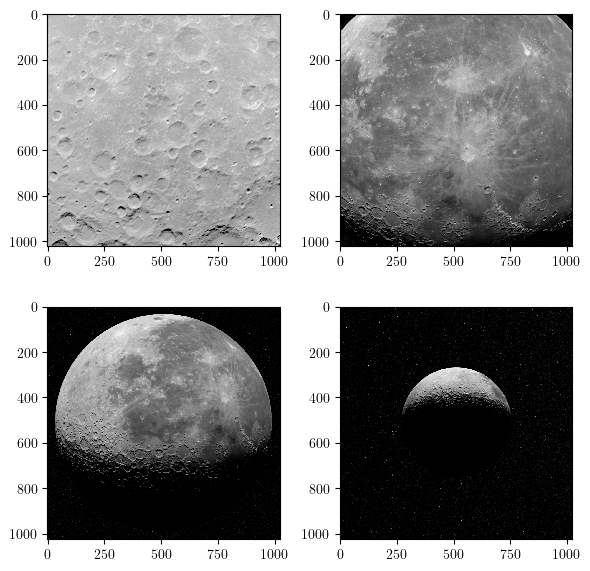

In [19]:
from PIL import Image

fig = plt.figure(figsize=(6, 6))
i = 0
for k, j in enumerate([0, 9, 15, 60]):
    t = t_cam[j]
    img = Image.open(os.path.join(outdir, f"sc_{i}", f"img_{t:04d}.png"))
    plt.subplot(2, 2, k + 1)
    plt.imshow(img, aspect="equal", interpolation="none", cmap="gray")
plt.tight_layout()
plt.savefig("../figures/craters/camera_samples.pdf")
plt.show()

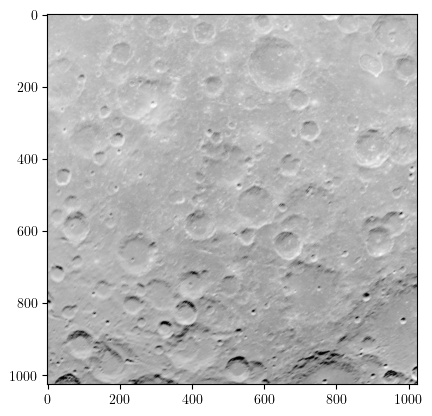

In [20]:
# Params
i = 0
t = t_cam[15]
t = t_cam[0]
r_cam_pa = rv_m2sc_pa[i, t, 0:3]
R_pa2ocv = R_sc2ocv @ R_mi2sc[i, t] @ R_pa2mi[t]
r_sun_pa = rv_m2s_pa[t, 0:3]
R_pa2cam = R_pa2ocv
R_cam2pa = R_pa2cam.T
filepath = os.path.join(outdir, f"sample{t:04d}.png")

img = Image.open(filepath)
plt.imshow(img, cmap="gray")

In [21]:
from pylupnt.crater_detection.common.robbins import (
    load_craters,
    extract_robbins_dataset,
)

from pylupnt.crater_detection.common.conics import (
    plot_conics,
    ellipse_axes,
    scale_det,
    conic_center,
    ellipse_angle,
    conic_matrix,
    project_crater_centers,
)

from pylupnt.crater_detection.common.coordinates import ENU_system, nadir_attitude

lat_crater, lon_crater, a_crater, b_crater, psi_crater, id_crater = (
    extract_robbins_dataset(
        load_craters(
            pnt.find_file("lunar_crater_database_robbins_2018.csv"),
            diamlims=[20, 250],
            ellipse_limit=1.4,
        )
    )
)

In [22]:
r_M = r_cam_pa[:, None]
T_CM = R_cam2pa

r_geo = np.vstack((lat_crater, lon_crater, np.zeros_like(lat_crater))).T
p_Mi = pnt.geographical_to_cartesian(r_geo, pnt.R_MOON)[:, :, None]

# Visibility
height = np.linalg.norm(r_M) - pnt.R_MOON
dist = height / np.cos(np.radians(fov_cam / 2) * np.sqrt(2) * 1.5)
vis_crater = (np.sqrt(np.sum(np.square(p_Mi - r_M), axis=1)) < dist).ravel()
# Sun angle
e1 = p_Mi.squeeze() / np.linalg.norm(p_Mi.squeeze(), axis=1)[:, None]
e2 = r_sun_pa / np.linalg.norm(r_sun_pa)
vis_crater &= np.einsum("ij,j->i", e1, e2) > -0.05
# Spacecraft angle
e1 = p_Mi.squeeze() / np.linalg.norm(p_Mi.squeeze(), axis=1)[:, None]
e2 = r_cam_pa / np.linalg.norm(r_cam_pa)
vis_crater &= np.einsum("ij,j->i", e1, e2) > 0.5
# Camera frame
r_center = project_crater_centers(p_Mi[vis_crater], fov_cam, res_cam, T_CM, r_M)
margin = 0.0
vis_crater2 = np.logical_and.reduce(
    (
        r_center[:, 0] > margin * res_cam[0],
        r_center[:, 0] < (1 - margin) * res_cam[0],
        r_center[:, 1] > margin * res_cam[1],
        r_center[:, 1] < (1 - margin) * res_cam[1],
    )
)
r_center = r_center[vis_crater2]
vis_crater[vis_crater] &= vis_crater2
p_Mi = p_Mi[vis_crater]

T_EM = np.concatenate(ENU_system(p_Mi), axis=-1)
S = np.concatenate((np.identity(2), np.zeros((1, 2))), axis=0)
H_Mi = np.concatenate((T_EM @ S, p_Mi), axis=-1)

k = np.array([0.0, 0.0, 1.0])[:, None]
T_MC = np.linalg.inv(T_CM)
r_C = T_MC @ r_M
# P_MC = K @ np.concatenate((T_MC, -r_C), axis=1)
P_MC = K @ T_MC @ np.concatenate((np.identity(3), -r_M), axis=1)
H_Ci = P_MC @ np.concatenate((H_Mi, np.tile(k.T[None, ...], (len(H_Mi), 1, 1))), axis=1)

C_i = conic_matrix(a_crater[vis_crater], b_crater[vis_crater], psi_crater[vis_crater])
A_i = np.linalg.inv(H_Ci).transpose((0, 2, 1)) @ C_i @ np.linalg.inv(H_Ci)

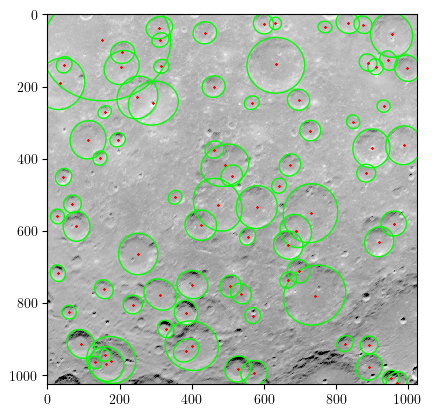

In [23]:
a_proj, b_proj = ellipse_axes(A_i)
psi_proj = ellipse_angle(A_i)
r_pix_proj = conic_center(A_i)

from matplotlib.collections import EllipseCollection

fig, ax = plt.subplots(subplot_kw={"aspect": "equal"})
plt.imshow(img, aspect="equal", interpolation="none", cmap="gray")
ec = EllipseCollection(
    a_proj,
    b_proj,
    np.degrees(psi_proj),
    units="xy",
    offsets=r_pix_proj,
    transOffset=ax.transData,
    facecolors="None",
    edgecolors="lime",
)
ax.add_collection(ec)

plt.scatter(
    *project_crater_centers(p_Mi, fov_cam, res_cam, T_CM, r_M).T,
    c="r",
    s=1.2,
    marker="x"
)

plt.xlim(0, res_cam[0])
plt.ylim(res_cam[1], 0)

plt.show()

In [24]:
sigma_pix = 1
A_craters = A_i

n_det = len(A_craters)
major_det, minor_det = ellipse_axes(A_craters)
psi_det = ellipse_angle(A_craters)
r_craters_det = conic_center(A_craters)

major_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
minor_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
psi_det += np.random.normal(scale=(20 / 180) * np.pi, size=n_det)
r_craters_det += np.random.normal(-sigma_pix, sigma_pix, size=r_craters_det.shape)

A_detections = conic_matrix(major_det, minor_det, psi_det, *r_craters_det.T)

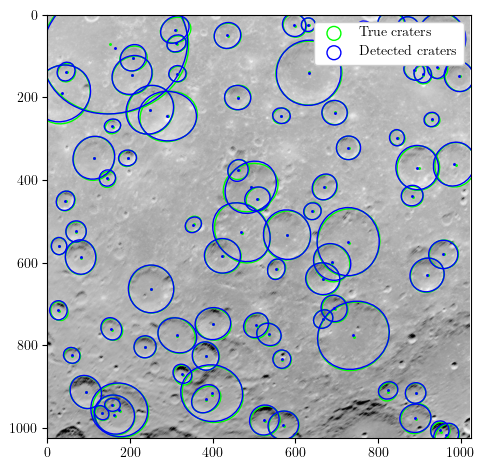

In [25]:
plt.figure()
ax = plt.gca()
plt.imshow(img, cmap="gray")
plot_conics(A_craters, rim_color="lime", ax=ax, resolution=res_cam)
plot_conics(A_detections, rim_color="blue", ax=ax, resolution=res_cam)
plt.scatter(*r_center.T, c="lime", s=1.2, marker="o")
plt.scatter(*r_craters_det.T, c="blue", s=1.2, marker="o")
plt.scatter(
    [], [], marker="o", label="True craters", facecolor="none", s=100, edgecolor="lime"
)
plt.scatter(
    [],
    [],
    marker="o",
    label="Detected craters",
    facecolor="none",
    s=100,
    edgecolor="blue",
)
plt.legend(loc="upper right", framealpha=1)
plt.tight_layout()
plt.savefig(f"../figures/craters/ellipse_detection_{t}.pdf")
plt.show()

In [26]:
T_EM = np.concatenate(ENU_system(p_Mi), axis=-1)
T_ME = np.linalg.inv(T_EM)

B_craters = R_cam2pa @ K.T @ A_detections @ K @ R_pa2cam
A_lstsq = (S.T @ T_ME @ B_craters).reshape(-1, 3)
b_lstsq = (S.T @ T_ME @ B_craters @ p_Mi).reshape(-1)

In [27]:
r_lstsq = np.linalg.lstsq(A_lstsq, b_lstsq, rcond=None)[0]
r_lstsq2 = pnt.crater_detection.crater_detection.crater_detection(
    r_cam_pa, R_pa2cam, r_sun_pa, fov_cam, res_cam
)
r_lstsq, r_lstsq2, r_cam_pa

(array([ -565.4138932 , -1009.00653985,  2115.37848196]),
 array([ -565.46885432, -1009.22790168,  2114.71874119]),
 array([ -565.02724801, -1010.00082268,  2114.85204854]))

# Horizon Matching

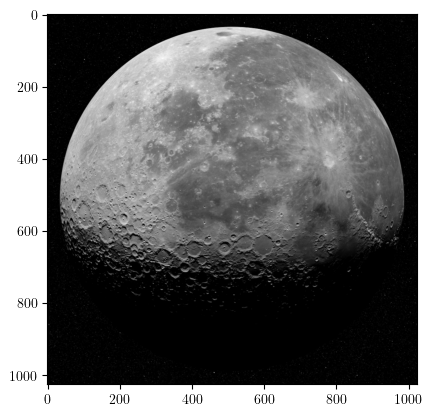

In [28]:
i = 0
t = t_cam[15]
r_cam_pa = rv_m2sc_pa[i, t, 0:3]
R_pa2ocv = R_sc2ocv @ R_mi2sc[i, t] @ R_pa2mi[t]
r_sun_pa = rv_m2s_pa[t, 0:3]

R_pa2cam = R_pa2ocv
R_cam2pa = R_pa2cam.T
filepath = os.path.join(outdir, f"sample{t:04d}.png")

img = Image.open(filepath)
plt.imshow(img, cmap="gray")

In [29]:
u_illum = -np.array([[1, 0, 0], [0, 1, 0]]) @ R_pa2cam @ r_sun_pa
u_illum /= np.linalg.norm(u_illum)
u_illum

array([5.61385058e-18, 1.00000000e+00])

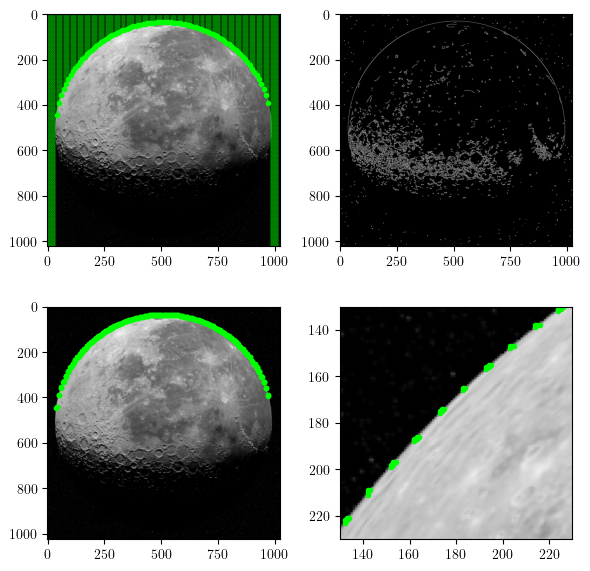

In [30]:
from scipy.ndimage import binary_dilation


def trace_lines_and_record(img, u_illum, N_lines, threshold, return_lines=False):
    img_array = np.array(img)
    height, width = img_array.shape
    mask = np.zeros_like(img_array)
    mask_lines = np.zeros_like(img_array)

    # Calculate starting points along the borders
    start_points = []
    start_points.extend(
        [(0, int(y)) for y in np.linspace(0, height, N_lines // 2, endpoint=False)]
    )
    start_points.extend(
        [(int(x), 0) for x in np.linspace(0, width, N_lines // 2, endpoint=False)]
    )
    for start in start_points:
        x, y = start
        while 0 <= x < width and 0 <= y < height:
            if img_array[y, x] > threshold:
                mask[y, x] = 1
                break
            else:
                mask_lines[y, x] = 1
            x += int(np.round(u_illum[0]))
            y += int(np.round(u_illum[1]))

    if return_lines:
        return mask, mask_lines

    return mask


# Get the mask
N_lines = 200
threshold = 110
mask, mask_lines = trace_lines_and_record(
    img, u_illum, N_lines, threshold, return_lines=True
)

# Canny edge detection
import cv2

edges = cv2.Canny(np.array(img), 100, 200)

# Dilate the mask
structure = np.ones((3, 3))
dilated_mask = binary_dilation(mask, structure=structure).astype(mask.dtype)
final_mask = dilated_mask * edges

# Display the image and the mask
plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
for u, v in zip(*np.where(mask_lines.T)):
    plt.plot(u, v, "o", markersize=0.05, color="lime")
for u, v in zip(*np.where(mask.T)):
    plt.plot(u, v, "o", markersize=3, color="lime")

plt.subplot(2, 2, 2)
plt.imshow(edges, cmap="gray")

plt.subplot(2, 2, 3)
plt.imshow(img, cmap="gray")
for u, v in zip(*np.where(final_mask.T)):
    plt.plot(u, v, "o", markersize=3, color="lime")

plt.subplot(2, 2, 4)
plt.imshow(img, cmap="gray")
for u, v in zip(*np.where(final_mask.T)):
    plt.plot(u, v, "o", markersize=3, color="lime")
plt.xlim(130, 230)
plt.ylim(130, 230)
plt.gca().invert_yaxis()
plt.tight_layout()
if flag_save:
    plt.savefig("../figures/horizon/detection.pdf")
plt.show()

In [32]:
uv_horizon = np.ones((np.count_nonzero(final_mask), 3))
uv_horizon[:, :2] = np.vstack(np.where(final_mask)).T

r_cam_pa_horizon = pnt.crater_detection.crater_detection.horizon_detection(
    img, R_pa2cam, r_sun_pa, K, N_lines=200, threshold=110
)
r_cam_pa_horizon *= np.sign(r_cam_pa_horizon @ r_cam_pa)
r_cam_pa, r_cam_pa_horizon

(array([ 4525.58970013, -1093.97488333, -1291.58411396]),
 array([ 4523.58021036, -1090.92526242, -1289.65751026]))

In [113]:
r_crater = np.zeros((N_sat, N_t_cam, 3))
r_horizon = np.zeros((N_sat, N_t_cam, 3))
P_r_mi_diag = np.zeros((N_sat, N_t_cam, 3))
sigma_pix = 2

for t_, t in tqdm(enumerate(t_cam), total=len(t_cam)):
    for i in range(N_sat):
        r_cam_pa = rv_m2sc_pa[i, t, 0:3]
        R_pa2ocv = R_sc2ocv @ R_mi2sc[i, t] @ R_pa2mi[t]
        r_sun_pa = rv_m2s_pa[t, 0:3]
        R_pa2cam = R_pa2ocv
        img = Image.open(os.path.join(outdir, f"sc_{i}", f"img_{t:04d}.png"))
        r_crater_pa = pnt.crater_detection.crater_detection.crater_detection(
            r_cam_pa, R_pa2cam, r_sun_pa, fov_cam, res_cam, alpha_sun=-0.2, alpha_cam=0.3,
        )
        r_crater[i, t_] = R_pa2mi[t] @ r_crater_pa

        r_horizon_pa, P_r_pa = pnt.crater_detection.crater_detection.horizon_detection(
            img, R_pa2cam, r_sun_pa, K, f_x, sigma_pix, N_lines=400, threshold=120
        )
        r_horizon_pa *= np.sign(r_horizon_pa @ r_cam_pa)
        r_horizon[i, t_] = R_pa2mi[t] @ r_horizon_pa
        P_r_mi_diag[i, t_] = np.diag(R_pa2mi[t] @ P_r_pa @ R_pa2mi[t].T)

  0%|          | 0/65 [00:00<?, ?it/s]

In [114]:
r_err_crater = r_crater - rv_m2sc_mi[:, t_cam, :3]
r_err_horizon = r_horizon - rv_m2sc_mi[:, t_cam, :3]

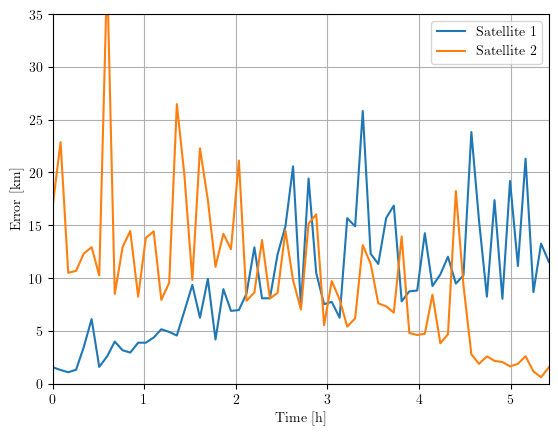

In [104]:
plt.figure()
plt.plot(tspan_h[t_cam], np.linalg.norm(r_err_crater, axis=-1).T)
plt.xlabel("Time [h]")
plt.ylabel("Error [km]")
plt.legend([f"Satellite {i+1}" for i in range(N_sat)])
plt.grid()
plt.xlim(tspan_h[0], tspan_h[-1])
plt.ylim(0, 35)
plt.savefig("../figures/craters/crater_detection_error.pdf")
plt.show()

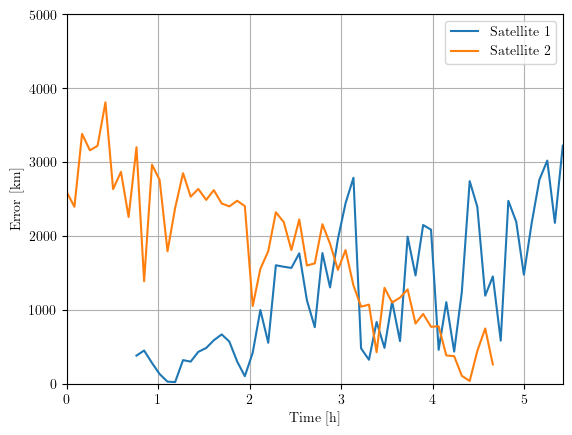

In [174]:
idxs = np.linalg.norm(rv_m2sc_mi[:, t_cam, :3], axis=-1) > 3.5e3
plt.figure()
for i in range(N_sat):
    plt.plot(tspan_h[t_cam[idxs[i]]], np.linalg.norm(r_err_horizon, axis=-1)[i,idxs[i]], color=pnt.plot.COLORS[i])
plt.xlabel("Time [h]")
plt.ylabel("Error [km]")
plt.legend([f"Satellite {i+1}" for i in range(N_sat)])
plt.grid()
plt.xlim(tspan_h[0], tspan_h[-1])
plt.ylim(0, 5000)
plt.savefig("../figures/horizon/horizon_detection_error.pdf")
plt.show()

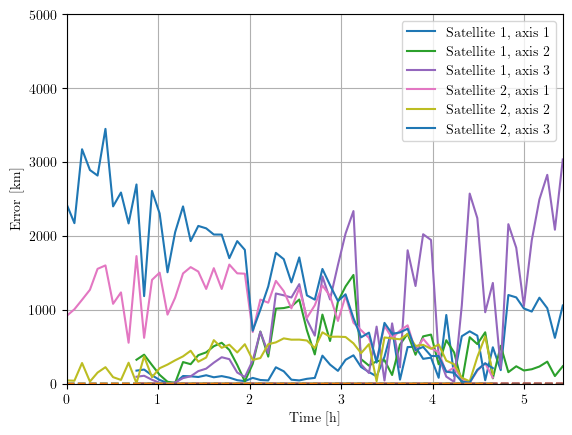

In [117]:
idxs = np.linalg.norm(rv_m2sc_mi[:, t_cam, :3], axis=-1) > 3.5e3
plt.figure()
for i in range(N_sat):
    for j in range(3):
        plt.plot(tspan_h[t_cam[idxs[i]]], np.abs(r_err_horizon[i,idxs[i],j]), label=f"Satellite {i+1}, axis {j+1}")
        plt.plot(tspan_h[t_cam[idxs[i]]], np.sqrt(P_r_mi_diag[i,idxs[i],j]), linestyle="--")
plt.xlabel("Time [h]")
plt.ylabel("Error [km]")
plt.legend()
plt.grid()
plt.xlim(tspan_h[0], tspan_h[-1])
plt.ylim(0, 5000)
# plt.savefig("../figures/horizon/horizon_detection_error.pdf")
plt.show()


# Filtering

In [169]:
sigma_gnss = 10  # [m]
sigma_isl = 10  # [m]
sigma_isl_clk = 20 # [m]
sigma_crater = 5  # [m]
sigma_horizon = 100  # [m]
r_idx = [0, 1, 2, 6]
v_idx = [3, 4, 5, 7]

x_true = np.concatenate([rv_m2sc_mi, clk], axis=-1)  # [km, km/s, s, s/s]


def block_diag(*arrs):
    """Create a block diagonal matrix from the input arrays."""
    arrs2 = [np.atleast_2d(a) for a in arrs]
    shapes = np.array([a.shape for a in arrs2])
    out = np.zeros(np.sum(shapes, axis=0), dtype=arrs2[0].dtype)
    r, c = 0, 0
    for i, (rr, cc) in enumerate(shapes):
        out[r : r + rr, c : c + cc] = arrs2[i]
        r += rr
        c += cc
    return out


def run_filter(measurements=None, seed=0):
    np.random.seed(seed)
    
    if measurements is None:
        measurements = []
    # State [x, y, z, vx, vy, vz, b, d] [km, km/s, km, km/s]
    x = np.zeros((N_sat, N_t, 8))
    P = np.zeros((N_sat, N_t, 8, 8))
    x_pred = np.zeros((N_sat, N_t, 8))
    P_pred = np.zeros((N_sat, N_t, 8, 8))

    sigma_r = 100 * 1e-3  # [km]
    sigma_v = 0.1 * 1e-3  # [km/s]
    P0 = np.zeros((8, 8))
    P0[:3, :3] = sigma_r**2 * np.eye(3)
    P0[3:6, 3:6] = sigma_v**2 * np.eye(3)
    P0[6, 6] = (sigma_r / pnt.C) ** 2
    P0[7, 7] = (sigma_v / pnt.C) ** 2

    x[:, 0] = x_true[:, 0] + np.random.multivariate_normal(np.zeros(8), P0, N_sat)

    sigma_acc = 4e-7  # [km/s^2]
    Q_rv = orbit_process_noise(sig_acc=sigma_acc, dt=dt)

    for t in tqdm(range(1, N_t)):
        for i in range(N_sat):

            # Time update
            x_rv_pred, stm_rv = dyn_ekf.propagate_with_stm(
                x[i, t - 1, 0:6], t_tai[t - 1], t_tai[t], dt_prop
            )
            x_clk_pred = stm_clk @ x[i, t - 1, 6:8]
            P_rv_pred = stm_rv @ P[i, t - 1, 0:6, 0:6] @ stm_rv.T + Q_rv
            P_clk_pred = stm_clk @ P[i, t - 1, 6:8, 6:8] @ stm_clk.T + Q_clk

            x_pred[i, t, 0:6] = x_rv_pred
            x_pred[i, t, 6:8] = x_clk_pred
            P_pred[i, t, 0:6, 0:6] = P_rv_pred
            P_pred[i, t, 6:8, 6:8] = P_clk_pred

        for i in range(N_sat):
            # Measurement update
            y, y_est, H, R = [], [], [], []
            # ************************************************************************
            N_gnss = np.sum(vis_sat_gps[i, :, t])
            if "GNSS" in measurements and N_gnss > 0:
                y_gnss = np.zeros(N_gnss)
                y_gnss_est = np.zeros(N_gnss)
                H_gnss = np.zeros((N_gnss, 8))
                R_gnss = sigma_gnss**2 * np.eye(N_gnss)
                k = 0
                for j in range(N_gps):
                    if vis_sat_gps[i, j, t]:
                        r = rv_gps_mi[j, t, :3] - x_true[i, t, :3] 
                        r_est = rv_gps_mi[j, t, :3] - x_pred[i, t, :3]
                        y_gnss[k] = np.linalg.norm(r) + x_true[i, t, 6] + np.random.normal(0, sigma_gnss)
                        y_gnss_est[k] = np.linalg.norm(r_est) + x_pred[i, t, 6]
                        H_gnss[k, :3] = -r_est / np.linalg.norm(r_est)
                        H_gnss[k, 6] = 0.1
                        k += 1
                y = np.concatenate((y, y_gnss))
                y_est = np.concatenate((y_est, y_gnss_est))
                H = np.vstack((H, H_gnss)) if len(H) > 0 else H_gnss
                R = block_diag(R, R_gnss) if len(R) > 0 else R_gnss
            # ************************************************************************
            N_isl = np.sum(vis_sat_sat[i, :, t])
            if "ISL" in measurements and N_isl > 0:
                y_isl = np.zeros(2 * N_isl)
                y_isl_est = np.zeros(2 * N_isl)
                H_isl = np.zeros((2 * N_isl, 8))
                R_isl = np.diag([sigma_isl**2, sigma_isl_clk**2])
                k = 0
                for j in range(N_sat):
                    if vis_sat_sat[i, j, t]:
                        r = x_true[j, t, :3] - x_true[i, t, :3]
                        r_est = x_true[j, t, :3] - x_pred[i, t, :3]
                        y_isl[2 * k] = np.linalg.norm(r) + np.random.normal(0, sigma_isl)
                        y_isl_est[2 * k] = np.linalg.norm(r_est)
                        y_isl[2 * k + 1] = x_true[j, t, 6] - x_true[i, t, 6]
                        y_isl_est[2 * k + 1] = x_pred[j, t, 6] - x_pred[i, t, 6]
                        H_isl[2 * k, :3] = -r_est / np.linalg.norm(r_est)
                        H_isl[2 * k + 1, 6] = 1
                        k += 1
                y = np.concatenate((y, y_isl.flatten()))
                y_est = np.concatenate((y_est, y_isl_est.flatten()))
                H = np.vstack((H, H_isl)) if len(H) > 0 else H_isl
                R = block_diag(R, R_isl) if len(R) > 0 else R_isl
            # ************************************************************************
            if t in t_cam and ("crater" in measurements or "horizon" in measurements):
                r_cam_pa = rv_m2sc_pa[i, t, 0:3]
                R_pa2ocv = R_sc2ocv @ R_mi2sc[i, t] @ R_pa2mi[t]
                r_sun_pa = rv_m2s_pa[t, 0:3]
                R_pa2cam = R_pa2ocv
                img = Image.open(os.path.join(outdir, f"sc_{i}", f"img_{t:04d}.png"))
            # ************************************************************************
            if "crater" in measurements and t in t_cam:
                y_crater = pnt.crater_detection.crater_detection.crater_detection(
                    r_cam_pa, R_pa2cam, r_sun_pa, fov_cam, res_cam, alpha_sun=-0.2, alpha_cam=0.3,
                )
                y_crater = R_pa2mi[t] @ y_crater
                R_crater = sigma_crater**2 * np.eye(3)
                H_crater = np.zeros((3, 8))
                H_crater[:, :3] = np.eye(3)
                y = np.concatenate((y, y_crater))
                y_est = np.concatenate((y_est, y_crater))
                H = np.vstack((H, H_crater)) if len(H) > 0 else H_crater
                R = block_diag(R, R_crater) if len(R) > 0 else R_crater
            # ************************************************************************
            if "horizon" in measurements and t in t_cam and np.linalg.norm(r_cam_pa) > 3.5e3:
                y_horizon, _ = pnt.crater_detection.crater_detection.horizon_detection(
                    img, R_pa2cam, r_sun_pa, K, f_x, sigma_pix, N_lines=100, threshold=110
                )
                y_horizon *= np.sign(y_horizon @ r_cam_pa)
                y_horizon = R_pa2mi[t] @ y_horizon
                R_horizon = sigma_horizon**2 * np.eye(3)
                H_horizon = np.zeros((3, 8))
                H_horizon[:, :3] = np.eye(3)
                y = np.concatenate((y, y_horizon))
                y_est = np.concatenate((y_est, y_horizon))
                H = np.vstack((H, H_horizon)) if len(H) > 0 else H_horizon
                R = block_diag(R, R_horizon) if len(R) > 0 else R_horizon
            # ************************************************************************

            if len(y) > 0:
                K_ = P_pred[i, t] @ H.T @ np.linalg.inv(H @ P_pred[i, t] @ H.T + R)
                x[i, t, :] = x_pred[i, t, :] + K_ @ (y - y_est)
                P[i, t, :, :] = (np.eye(8) - K_ @ H) @ P_pred[i, t, :, :] @ (
                    np.eye(8) - K_ @ H
                ).T + K_ @ R @ K_.T
            else:
                x[i, t, :] = x_pred[i, t, :]
                P[i, t, :, :] = P_pred[i, t, :, :]

    x_error = x - x_true
    x_sigma = np.zeros((N_sat, N_t, 8))
    for i in range(N_sat):
        for t in range(N_t):
            x_sigma[i, t] = np.sqrt(np.diag(P[i, t]))

    x_error[:, :, r_idx] *= 1e3  # [m]
    x_error[:, :, v_idx] *= 1e6  # [mm/s]
    x_sigma[:, :, r_idx] *= 1e3  # [m]
    x_sigma[:, :, v_idx] *= 1e6  # [mm/s]
    return x, P, x_error, x_sigma

In [170]:
def plot_errors(x_error, x_sigma):
    plt.figure(figsize=(10, 5))
    N_sigma = 3
    r_labels = ["$x$ [m]", "$y$ [m]", "$z$ [m]", "$b$ [m]"]
    v_labels = ["$v_x$ [mm/s]", "$v_y$ [mm/s]", "$v_z$ [mm/s]", "$d$ [mm/s]"]

    # Limits
    er_max = max(np.max(x_error[:, :, :3]), N_sigma * np.max(x_sigma[:, :, :3]))
    er_min = min(np.min(x_error[:, :, :3]), -N_sigma * np.max(x_sigma[:, :, :3]))
    ev_max = max(np.max(x_error[:, :, 3:6]), N_sigma * np.max(x_sigma[:, :, 3:6]))
    ev_min = min(np.min(x_error[:, :, 3:6]), -N_sigma * np.max(x_sigma[:, :, 3:6]))
    eb_max = max(np.max(x_error[:, :, 6]), N_sigma * np.max(x_sigma[:, :, 6]))
    eb_min = min(np.min(x_error[:, :, 6]), -N_sigma * np.max(x_sigma[:, :, 6]))
    # Position
    for i in range(4):
        plt.subplot(4, 2, 2 * i + 1)
        for j in range(N_sat):
            plt.plot(
                tspan_h,
                x_error[j, :, r_idx[i]],
                color=pnt.plot.COLORS[j],
                label=f"Satellite {j+1}",
            )
            plt.fill_between(
                tspan_h,
                -N_sigma * x_sigma[j, :, r_idx[i]],
                N_sigma * x_sigma[j, :, r_idx[i]],
                color=pnt.plot.COLORS[j],
                alpha=0.2,
            )
        plt.ylabel(r_labels[i])
        plt.xlim(tspan_h[0], tspan_h[-1])
        if i < 3:
            plt.ylim(er_min, er_max)
        plt.grid()
        if i == 0:
            plt.fill_between(
                [], [], [], color="gray", alpha=0.2, label=f"{N_sigma}$\sigma$ error"
            )
            plt.legend(loc="upper left", framealpha=1)
    plt.xlabel("Time [h]")
    # Velocity
    for i in range(4):
        plt.subplot(4, 2, 2 * i + 2)
        for j in range(N_sat):
            plt.plot(tspan_h, x_error[j, :, v_idx[i]], color=pnt.plot.COLORS[j])
            plt.fill_between(
                tspan_h,
                -N_sigma * x_sigma[j, :, v_idx[i]],
                N_sigma * x_sigma[j, :, v_idx[i]],
                color=pnt.plot.COLORS[j],
                alpha=0.2,
            )
        plt.ylabel(v_labels[i])
        plt.xlim(tspan_h[0], tspan_h[-1])
        if i < 3:
            plt.ylim(ev_min, ev_max)
        plt.grid()
    plt.xlabel("Time [h]")
    plt.tight_layout()

  0%|          | 0/1950 [00:00<?, ?it/s]

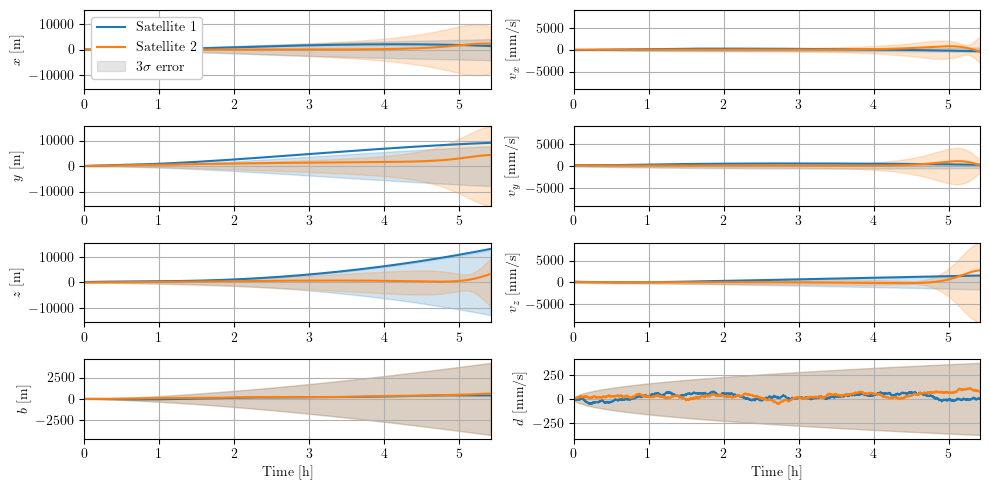

In [171]:
x, P, x_error, x_sigma = run_filter()
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/open_loop_errors.pdf")

  0%|          | 0/1950 [00:00<?, ?it/s]

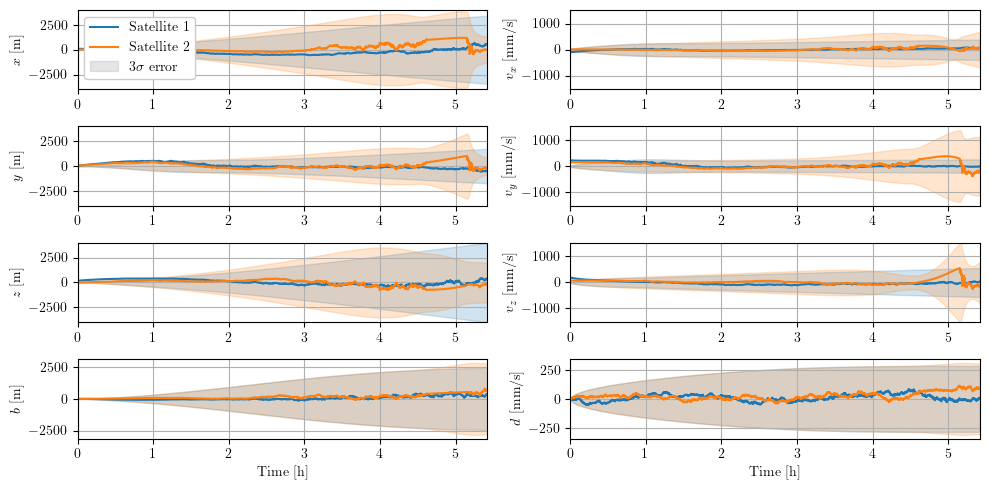

In [172]:
x, P, x_error, x_sigma = run_filter(["GNSS"])
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/gnss_errors.pdf")

  0%|          | 0/1950 [00:00<?, ?it/s]

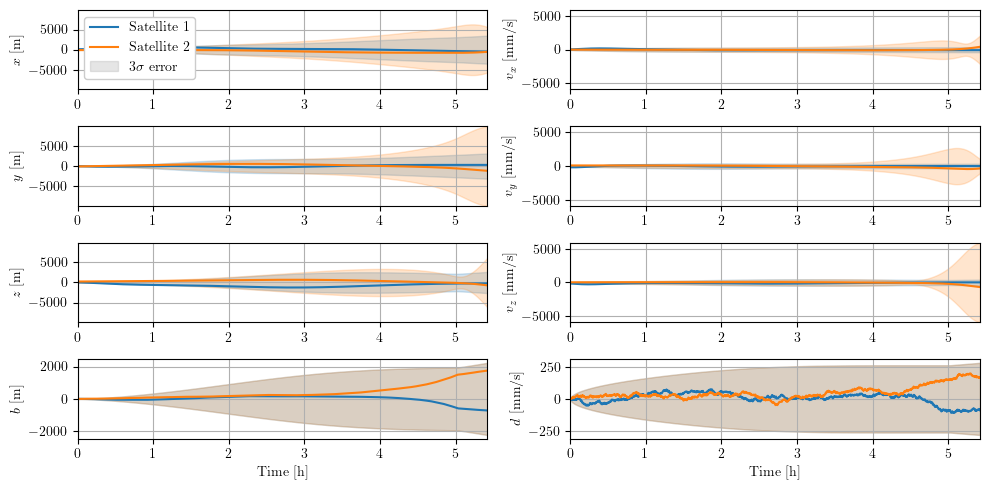

In [90]:
x, P, x_error, x_sigma = run_filter(["ISL"])
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/isl_errors.pdf")

  0%|          | 0/1950 [00:00<?, ?it/s]

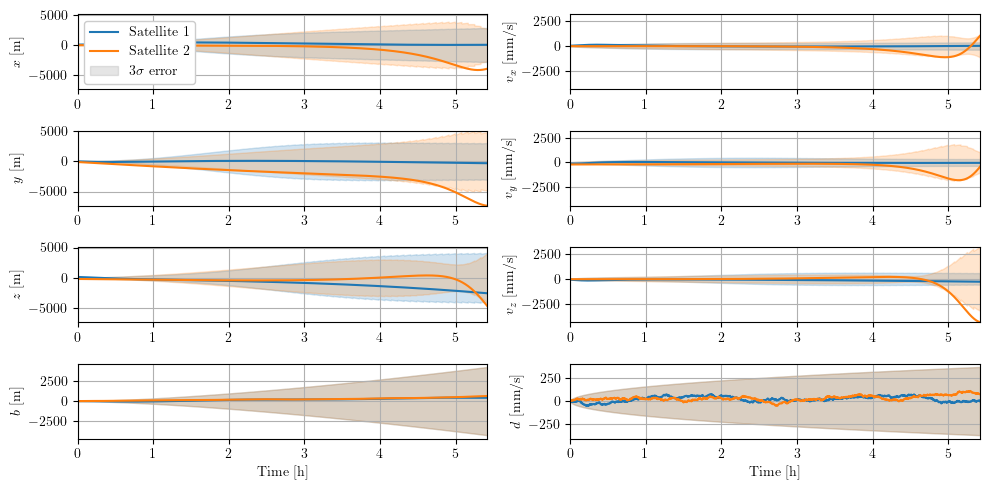

In [124]:
x, P, x_error, x_sigma = run_filter(["crater"])
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/crater_errors.pdf")

  0%|          | 0/1950 [00:00<?, ?it/s]

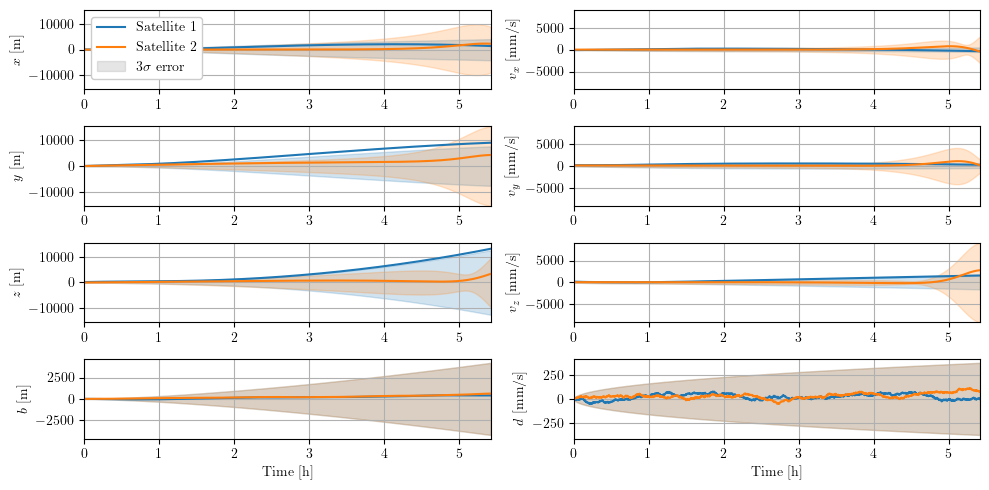

In [139]:
x, P, x_error, x_sigma = run_filter(["horizon"])
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/horizon_errors.pdf")

  0%|          | 0/1950 [00:00<?, ?it/s]

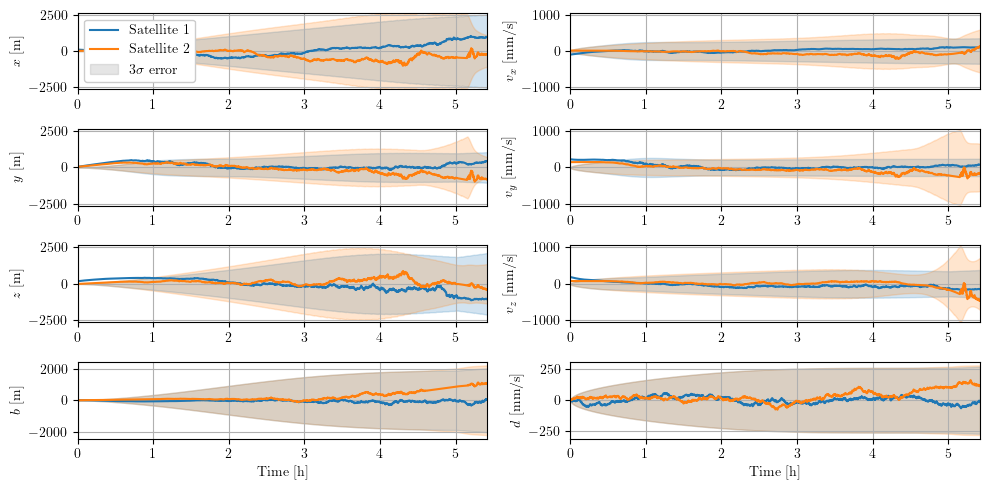

In [173]:
x, P, x_error, x_sigma = run_filter(["GNSS", "ISL", "crater", "horizon"])
plot_errors(x_error, x_sigma)
plt.savefig("../figures/filter/all_errors.pdf")